In [4]:
# %% [markdown]
# # Create TMO‑ready AnnData using peak annotation (gene‑level ATAC)
# This notebook uses the `atac_peak_annotation.tsv` file to map peaks to genes,
# aggregates peak accessibility per gene, and saves a combined AnnData for TMO.
# The fragment file is **not** required.

# %% [markdown]
# ## 1. Load MuData (already done, but we show the steps)

# %%
import muon as mu
import scanpy as sc
import anndata as ad
import numpy as np
import pandas as pd
from scipy.sparse import csr_matrix
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

# Path to the 10x Multiome H5 file (change to your location)
h5_file = Path("./10x_mouse_brain/e18_mouse_brain_fresh_5k_filtered_feature_bc_matrix.h5")

# Load MuData (RNA + ATAC)
mdata = mu.read_10x_h5(h5_file)
print(mdata)


C:\Users\phabe\miniconda3\envs\tmo_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Added `interval` annotation for features from 10x_mouse_brain\e18_mouse_brain_fresh_5k_filtered_feature_bc_matrix.h5
MuData object with n_obs × n_vars = 4881 × 176722
  var:	'gene_ids', 'feature_types', 'genome', 'interval'
  2 modalities
    rna:	4881 × 32285
      var:	'gene_ids', 'feature_types', 'genome', 'interval'
    atac:	4881 × 144437
      var:	'gene_ids', 'feature_types', 'genome', 'interval'


In [14]:
# %% [markdown]
# ## 2. Extract RNA raw counts and compute pseudotime

# %%
# RNA AnnData (raw counts)
rna = mdata['rna'].copy()
print(f"RNA shape: {rna.shape}")

# Normalise and compute pseudotime (first diffusion component)
sc.pp.normalize_total(rna, target_sum=1e4)
sc.pp.log1p(rna)
sc.pp.highly_variable_genes(rna, n_top_genes=2000, flavor='seurat')
sc.tl.pca(rna, n_comps=30, use_highly_variable=True)
sc.pp.neighbors(rna)
sc.tl.diffmap(rna, n_comps=15)
pseudotime = rna.obsm['X_diffmap'][:, 0]
pseudotime = (pseudotime - pseudotime.min()) / (pseudotime.max() - pseudotime.min())
rna.obs['pseudotime'] = pseudotime
print("Pseudotime range:", pseudotime.min(), "-", pseudotime.max())

RNA shape: (4881, 32285)
Pseudotime range: 0.0 - 1.0


In [17]:
# %% [markdown]
# ## 3. Build gene‑activity matrix from peak annotation TSV

# %%
# Path to the peak annotation file (change accordingly)
annot_file = Path("./10x_mouse_brain/e18_mouse_brain_fresh_5k_atac_peak_annotation.tsv")
annot = pd.read_csv(annot_file, sep='\t')
print(f"Annotation rows: {len(annot)}")

# Keep only rows with a valid gene name (non‑NaN)
annot = annot.dropna(subset=['gene'])
print(f"Rows with gene: {len(annot)}")

# Create mapping from peak name to list of gene names (a peak can map to multiple genes)
peak_to_genes = {}
for _, row in annot.iterrows():
    peak = row['peak']
    gene = row['gene']
    if peak not in peak_to_genes:
        peak_to_genes[peak] = []
    peak_to_genes[peak].append(gene)

# Get the peak matrix from the MuData object (cells × peaks)
peak_mat = mdata['atac'].X  # sparse matrix
peak_names = mdata['atac'].var_names

# Unique genes
all_genes = sorted(set(annot['gene']))
gene_to_idx = {g: i for i, g in enumerate(all_genes)}
n_cells = peak_mat.shape[0]
n_genes = len(all_genes)
print(f"Unique genes: {n_genes}")

# Initialise dense matrix (cells × genes) – may be memory heavy; we'll keep sparse later.
# For large numbers, we can build column by column. This is a simple loop over peaks.
# We'll accumulate in a dense array for simplicity (if memory permits), then convert to sparse.
X_gene = np.zeros((n_cells, n_genes), dtype=np.float32)

# Iterate over peaks (this may take a few minutes for 144k peaks)
print("Aggregating peak counts per gene...")
for i, peak_name in enumerate(peak_names):
    if i % 10000 == 0:
        print(f"Processed {i}/{len(peak_names)} peaks")
    if peak_name not in peak_to_genes:
        continue
    # Peak count vector (dense slice for this peak)
    peak_counts = peak_mat[:, i].toarray().flatten()
    for gene in peak_to_genes[peak_name]:
        j = gene_to_idx[gene]
        X_gene[:, j] += peak_counts

# Convert to sparse CSR for memory efficiency
X_gene_sparse = csr_matrix(X_gene)
print(f"Gene‑activity matrix shape: {X_gene_sparse.shape}")


Annotation rows: 144437
Rows with gene: 139001
Unique genes: 31036
Aggregating peak counts per gene...
Processed 0/144437 peaks
Processed 10000/144437 peaks
Processed 20000/144437 peaks
Processed 30000/144437 peaks
Processed 40000/144437 peaks
Processed 50000/144437 peaks
Processed 60000/144437 peaks
Processed 70000/144437 peaks
Processed 80000/144437 peaks
Processed 90000/144437 peaks
Processed 100000/144437 peaks
Processed 110000/144437 peaks
Processed 120000/144437 peaks
Processed 130000/144437 peaks
Processed 140000/144437 peaks
Gene‑activity matrix shape: (4881, 31036)


In [18]:
# %% [markdown]
# ## 4. Combine into TMO‑ready AnnData

# %%
# Use raw RNA counts (still in mdata['rna'].X). We'll create a new AnnData.
adata_tmo = ad.AnnData(
    X=mdata['rna'].X,          # raw RNA counts
    obs=rna.obs[['pseudotime']],  # pseudotime from the processed object
    var=mdata['rna'].var
)
# Add gene‑level ATAC matrix
adata_tmo.obsm['ATAC_gene'] = X_gene_sparse

# Ensure cell barcodes match (they should, because we used the same order)
print(f"Final TMO‑ready AnnData:")
print(f"RNA shape: {adata_tmo.shape}")
print(f"ATAC_gene shape: {adata_tmo.obsm['ATAC_gene'].shape}")
print(f"Pseudotime range: {adata_tmo.obs['pseudotime'].min():.3f} - {adata_tmo.obs['pseudotime'].max():.3f}")

Final TMO‑ready AnnData:
RNA shape: (4881, 32285)
ATAC_gene shape: (4881, 31036)
Pseudotime range: 0.000 - 1.000


Saved to mouse_brain_gene_level_tmo_ready.h5ad


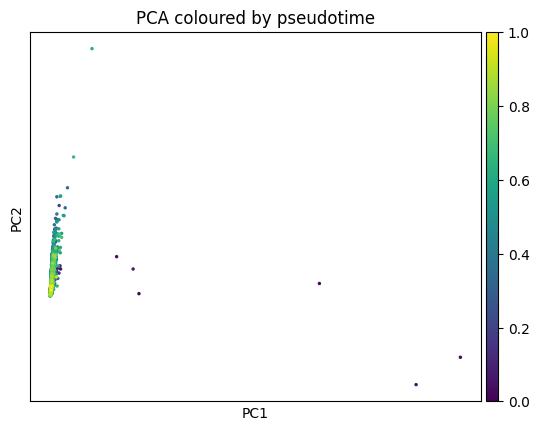

In [19]:
# %% [markdown]
# ## 5. Save to disk

# %%
output_file = "mouse_brain_gene_level_tmo_ready.h5ad"
adata_tmo.write(output_file, compression='gzip')
print(f"Saved to {output_file}")

# %% [markdown]
# ## 6. (Optional) Quick sanity check – PCA of RNA and visualise pseudotime

# %%
sc.pp.pca(adata_tmo, n_comps=2)
sc.pl.pca(adata_tmo, color='pseudotime', title="PCA coloured by pseudotime")

In [1]:
import anndata as ad
adata = ad.read_h5ad("mouse_brain_gene_level_tmo_ready.h5ad")
print("Shape:", adata.shape)
print("ATAC_gene shape:", adata.obsm['ATAC_gene'].shape)
print("Pseudotime range:", adata.obs['pseudotime'].min(), adata.obs['pseudotime'].max())

Shape: (4881, 32285)
ATAC_gene shape: (4881, 31036)
Pseudotime range: 0.0 1.0


C:\Users\phabe\miniconda3\envs\tmo_env\lib\site-packages\anndata\_core\anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [2]:
import numpy as np
from scipy.sparse import issparse

X = adata.obsm['ATAC_gene']
print("Sparse?", issparse(X))
if issparse(X):
    print("Non‑zero entries:", X.nnz)
    print("Fraction non‑zero:", X.nnz / (X.shape[0] * X.shape[1]))
    print("Sum over all cells per gene (first 10):", X.sum(axis=0).A1[:10])
else:
    print("Non‑zero entries:", np.count_nonzero(X))
    print("Mean:", np.mean(X))

Sparse? True
Non‑zero entries: 0
Fraction non‑zero: 0.0
Sum over all cells per gene (first 10): [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [6]:
print("MuData peak names (first 10):")
print(mdata['atac'].var_names[:10])

# Load annotation file and print first 10 peaks
import pandas as pd
annot = pd.read_csv("10x_mouse_brain/e18_mouse_brain_fresh_5k_atac_peak_annotation.tsv", sep='\t')
print("Annotation peak names (first 10):")
print(annot['peak'].head(10))

MuData peak names (first 10):
Index(['chr1:3094399-3095523', 'chr1:3113503-3114077', 'chr1:3119414-3121804',
       'chr1:3181343-3181401', 'chr1:3198296-3198611', 'chr1:3210204-3210605',
       'chr1:3292586-3292976', 'chr1:3371598-3371961', 'chr1:3399683-3400422',
       'chr1:3406113-3406524'],
      dtype='object')
Annotation peak names (first 10):
0    chr1_3094399_3095523
1    chr1_3113503_3114077
2    chr1_3119414_3121804
3    chr1_3181343_3181401
4    chr1_3198296_3198611
5    chr1_3210204_3210605
6    chr1_3292586_3292976
7    chr1_3371598_3371961
8    chr1_3399683_3400422
9    chr1_3406113_3406524
Name: peak, dtype: object


In [9]:
from scipy.sparse import lil_matrix, csr_matrix
import numpy as np

# Build mapping from peak index to list of gene indices
peak_to_gene_idx = {}
for i, peak_name in enumerate(peak_names_raw):
    norm_name = peak_name.replace(':', '_').replace('-', '_')
    genes = peak_to_genes.get(norm_name, [])
    if genes:
        peak_to_gene_idx[i] = [gene_to_idx[g] for g in genes]

# Create binary matrix M (peaks × genes) in LIL format
M = lil_matrix((len(peak_names_raw), n_genes), dtype=np.float32)
for p_idx, g_indices in peak_to_gene_idx.items():
    for g_idx in g_indices:
        M[p_idx, g_idx] = 1
M = M.tocsr()  # convert to CSR for fast multiplication

# Fast matrix multiplication: gene_activity = peak_matrix @ M
peak_matrix = mdata['atac'].X  # sparse (cells × peaks)
gene_activity = peak_matrix @ M   # (cells × genes)

print("Gene‑activity matrix shape:", gene_activity.shape)
print("Non‑zero entries:", gene_activity.nnz)

Gene‑activity matrix shape: (4881, 31036)
Non‑zero entries: 31574153


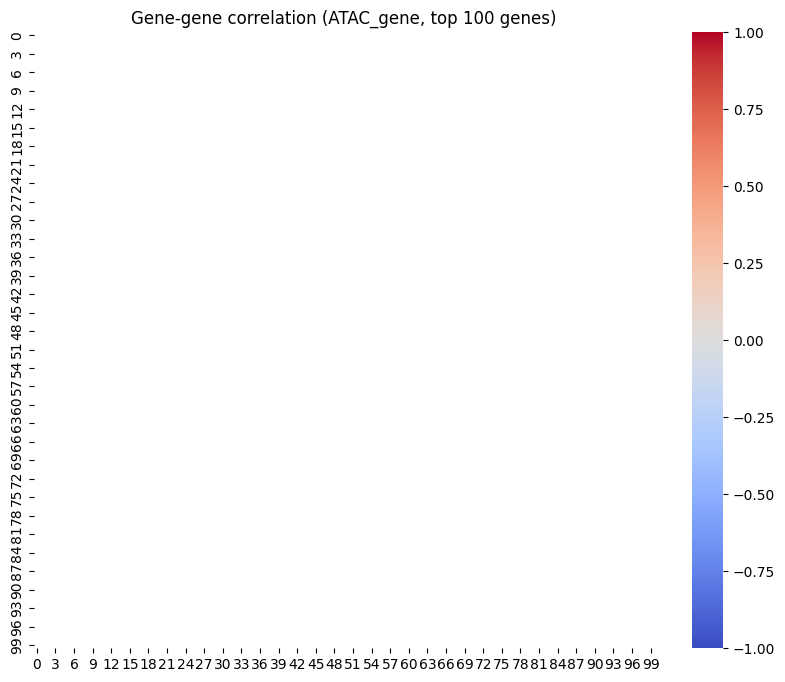

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse import issparse

# Load the gene‑level ATAC matrix
X = adata.obsm['ATAC_gene']
if issparse(X):
    # Convert to dense for a small subset of genes
    # First, compute mean accessibility per gene (to select top genes)
    means = X.mean(axis=0).A1
else:
    means = X.mean(axis=0)

# Select top 100 genes with highest mean accessibility
top_idx = np.argsort(-means)[:100]
X_sub = X[:, top_idx]
if issparse(X_sub):
    X_sub_dense = X_sub.toarray()
else:
    X_sub_dense = X_sub

# Compute correlation matrix (genes × genes)
corr = np.corrcoef(X_sub_dense.T)

# Plot
plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap='coolwarm', center=0, vmin=-1, vmax=1)
plt.title("Gene‑gene correlation (ATAC_gene, top 100 genes)")
plt.show()

C:\Users\phabe\miniconda3\envs\tmo_env\lib\site-packages\numpy\lib\function_base.py:2854: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]


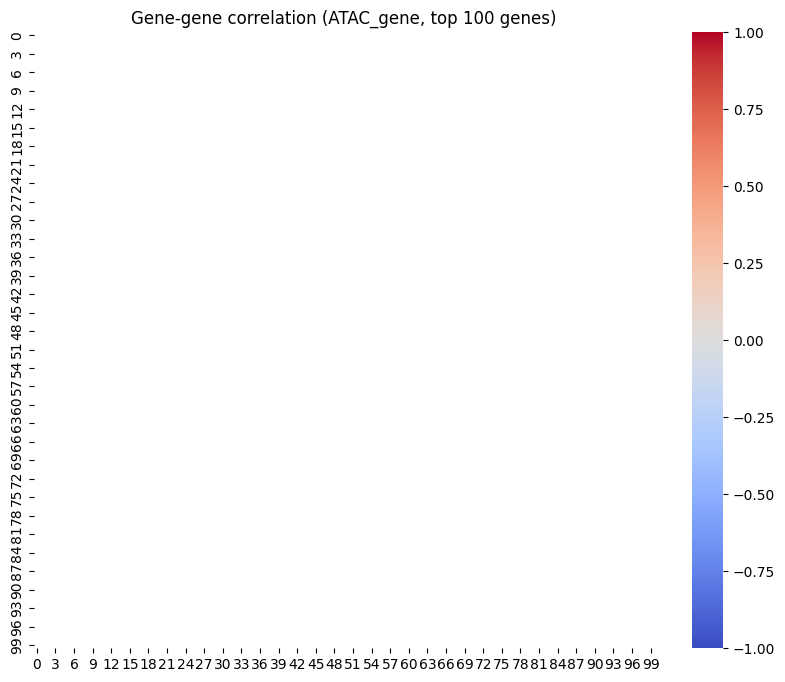

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse import issparse

# Load the gene‑level ATAC matrix
X = adata.obsm['ATAC_gene']
if issparse(X):
    # Convert to dense for a small subset of genes
    # First, compute mean accessibility per gene (to select top genes)
    means = X.mean(axis=0).A1
else:
    means = X.mean(axis=0)

# Select top 100 genes with highest mean accessibility
top_idx = np.argsort(-means)[:100]
X_sub = X[:, top_idx]
if issparse(X_sub):
    X_sub_dense = X_sub.toarray()
else:
    X_sub_dense = X_sub

# Compute correlation matrix (genes × genes)
corr = np.corrcoef(X_sub_dense.T)

# Plot
plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap='coolwarm', center=0, vmin=-1, vmax=1)
plt.title("Gene‑gene correlation (ATAC_gene, top 100 genes)")
plt.show()